In [1]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

In [2]:
df = pd.read_csv('spambase_csv.csv')
print(df.head())
print(df.isnull().sum())

   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00            0.00  ...           0.00          0.0

--- Exploratory Data Analysis (EDA) ---


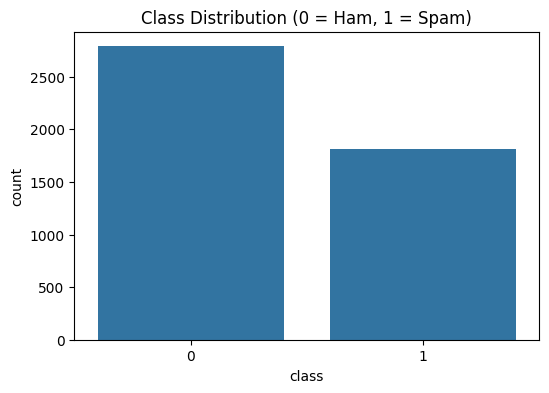

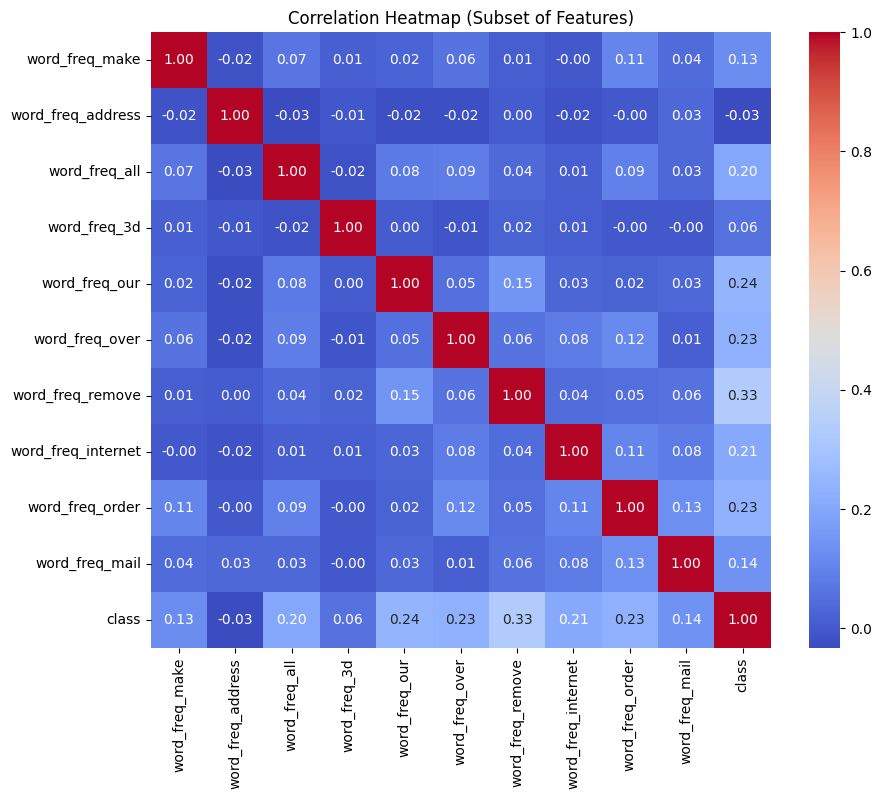

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('figures4', exist_ok=True)

print("Exploratory Data Analysis (EDA) ")
# 1. Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df)
plt.title('Class Distribution (0 = Ham, 1 = Spam)')
plt.savefig('figures4/class_distribution.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# 2. Correlation Heatmap (subset of 10 features to keep it readable)
plt.figure(figsize=(10, 8))
cols_to_plot = list(df.columns[:10]) + ['class']
sns.heatmap(df[cols_to_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Subset of Features)')
plt.savefig('figures4/correlation_heatmap.png', format='png', dpi=600, bbox_inches='tight')
plt.show()


In [4]:
y = df.pop('class')
X = df
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify = y)


In [ ]:
# Log-transform (handles zeros safely) followed by standardization
# log transformation also reduces right skewness for numerical features and compress large values
# logp => log(1+x) which is why it handles zero safely
preprocessor = Pipeline([
    ('log1p', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

In [ ]:
log_reg = LogisticRegression(max_iter=1000) # max_iter is set as a large value to provide more time for convergence
log_reg.fit(X_train_trans, y_train) # log reg inherently performs L2 regularisation
y_pred = log_reg.predict(X_test_trans)

In [ ]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_trans, y_train)

print("--- Logistic Regression ---")
print(classification_report(y_test, y_pred))

print("--- Kernel SVM (RBF) ---")
print(classification_report(y_test, svm_model.predict(X_test_trans))) # RBF can model complex relationships unlike linear 

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       558
           1       0.92      0.91      0.92       363

    accuracy                           0.94       921
   macro avg       0.93      0.93      0.93       921
weighted avg       0.94      0.94      0.94       921

--- Kernel SVM (RBF) ---
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       558
           1       0.94      0.91      0.92       363

    accuracy                           0.94       921
   macro avg       0.94      0.94      0.94       921
weighted avg       0.94      0.94      0.94       921



In [ ]:
# creating a grid search to tune hyperparams for Logistic Regression
param_grid = {
    'C': [ 0.01, 0.1, 1, 10, 100], # inverse strength of regularisation
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'] # both solvers support L1, L2
}

base_lr = LogisticRegression(max_iter=2000, random_state=42)

# Grid Search setup with 5-fold cross-validation
grid_lr = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid,
    cv=5,
    scoring='f1',       # Prioritizing F1-score for classification
    n_jobs=-1,          # Use all CPU cores
    verbose=1
)

# Fit on preprocessed training data
grid_lr.fit(X_train_trans, y_train)

# Output Best Hyperparameters
print(f"Best Parameters: {grid_lr.best_params_}")
print(f"Best CV F1-Score: {grid_lr.best_score_:.4f}")

# Evaluate tuned model on test set
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_trans)

print("\n--- Tuned Logistic Regression Test Performance ---")
print(classification_report(y_test, y_pred_lr))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1-Score: 0.9244

--- Tuned Logistic Regression Test Performance ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       558
           1       0.92      0.91      0.92       363

    accuracy                           0.93       921
   macro avg       0.93      0.93      0.93       921
weighted avg       0.93      0.93      0.93       921



c:\Users\Aadhithya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Aadhithya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [ ]:
# kernel based SVM hyperparameter tuning

param_grid = [
    {
        'kernel':['linear'],
        'C' : [0.1, 1, 10, 100]
    },
    {
        'kernel' : ['poly'],
        'C' : [0.1,1,10,100],
        'gamma' : ['scale', 'auto'],
        'degree' : [2,3,4]
    },
    {
        'kernel' : ['rbf', 'sigmoid'],
        'C' : [0.1,1,10,100],
        'gamma' : ['scale', 'auto']
    } # gamma=auto only depends on number of features whereas scale takes feature variance into account
]
base_svm = SVC(random_state=42)
grid_svm = GridSearchCV(
    estimator = base_svm,
    param_grid = param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_svm.fit(X_train_trans, y_train)
print(f"Best parameters: {grid_svm.best_params_}")
print(f"Best CV F1-Score: {grid_svm.best_score_:.4f}")

Fitting 5 folds for each of 44 candidates, totalling 220 fits
Best parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV F1-Score: 0.9357


In [10]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

start_time = time.time()
best_lr.fit(X_train_trans, y_train)
lr_train_time = time.time() - start_time

y_pred_lr = best_lr.predict(X_test_trans)

lr_results = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Training Time (s)'],
    'Value': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(precision_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_lr), 4),
        round(lr_train_time, 4)
    ]
}
df_lr = pd.DataFrame(lr_results)

# ==========================================
# 2. SVM KERNEL-WISE PERFORMANCE
# ==========================================
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svm_kernel_data = []

# Fetch best parameters from the fitted Grid Search per kernel
# (Assuming 'grid_svm' was already fitted using the parameter list)
cv_results = pd.DataFrame(grid_svm.cv_results_)

for kernel in kernels:
    # Filter grid search results for this kernel and get the best combination
    kernel_results = cv_results[cv_results['param_kernel'] == kernel].sort_values(by='mean_test_score', ascending=False)
    best_params_kernel = kernel_results.iloc[0]['params']

    # Instantiate model with optimal parameters for this specific kernel
    svm_model = SVC(**best_params_kernel, random_state=42)

    # Measure fit time on entire training set
    start_time = time.time()
    svm_model.fit(X_train_trans, y_train)
    train_time = time.time() - start_time

    # Predict and evaluate on test set
    y_pred = svm_model.predict(X_test_trans)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    svm_kernel_data.append({
        'Kernel': kernel.capitalize(),
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4),
        'Training Time (s)': round(train_time, 4)
    })

df_svm = pd.DataFrame(svm_kernel_data)

# Extract fold scores for the best estimator of each grid search
lr_fold_scores = [
    grid_lr.cv_results_[f'split{i}_test_score'][grid_lr.best_index_]
    for i in range(5)
]

svm_fold_scores = [
    grid_svm.cv_results_[f'split{i}_test_score'][grid_svm.best_index_]
    for i in range(5)
]

kfold_data = {
    'Fold': ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5', 'Average'],
    'Logistic Regression': [round(s, 4) for s in lr_fold_scores] + [round(np.mean(lr_fold_scores), 4)],
    'SVM': [round(s, 4) for s in svm_fold_scores] + [round(np.mean(svm_fold_scores), 4)]
}

df_kfold = pd.DataFrame(kfold_data)

# ==========================================
# DISPLAY ALL TABLES
# ==========================================
print("=== Logistic Regression Performance ===")
print(df_lr.to_string(index=False))

print("\n=== SVM Kernel-wise Performance ===")
print(df_svm.to_string(index=False))

print("\n=== K-Fold Cross-Validation Results (K = 5) ===")
print(df_kfold.to_string(index=False))

c:\Users\Aadhithya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Aadhithya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


=== Logistic Regression Performance ===
           Metric  Value
         Accuracy 0.9338
        Precision 0.9194
           Recall 0.9118
         F1 Score 0.9156
Training Time (s) 0.1083

=== SVM Kernel-wise Performance ===
 Kernel  Accuracy  F1 Score  Training Time (s)
 Linear    0.9305    0.9111             0.3546
   Poly    0.9349    0.9150             0.1602
    Rbf    0.9457    0.9306             0.1756
Sigmoid    0.9381    0.9201             0.2466

=== K-Fold Cross-Validation Results (K = 5) ===
   Fold  Logistic Regression    SVM
 Fold 1               0.9567 0.9432
 Fold 2               0.9220 0.9393
 Fold 3               0.9197 0.9422
 Fold 4               0.9072 0.9171
 Fold 5               0.9164 0.9366
Average               0.9244 0.9357
